Loading trades …
  Trading days in history : 445
  Mean daily P&L          : $32.32
  Std daily P&L           : $411.83
  % positive days         : 43.6%
  Best day                : $2,388.50
  Worst day               : $-1,264.00

Running 10,000 combine simulations …
  Pass rate        : 32.6%
  Blown rate       : 54.1%
  Gave up rate     : 13.4%
  Avg days to pass : 29.1
  Median days      : 27

Running 3,257 funded account simulations …
  Prob blown funded    : 90.7%
  Prob of any payout   : 74.4%
  Avg total payouts    : $2,192.37
  Avg # of payouts     : 2.7
  Avg net (after fees) : $2,072.06
  Cost if pass  : $217  (combine fees + activation)
  Cost if fail  : $140  (combine fees only)
  EV per attempt: $510
  Prob of profit: 24.2%

  Fee option comparison:
    Standard ($49/mo + $149 activation)  ->  EV = $510
    Express  ($109/mo, no activation)    ->  EV = $416


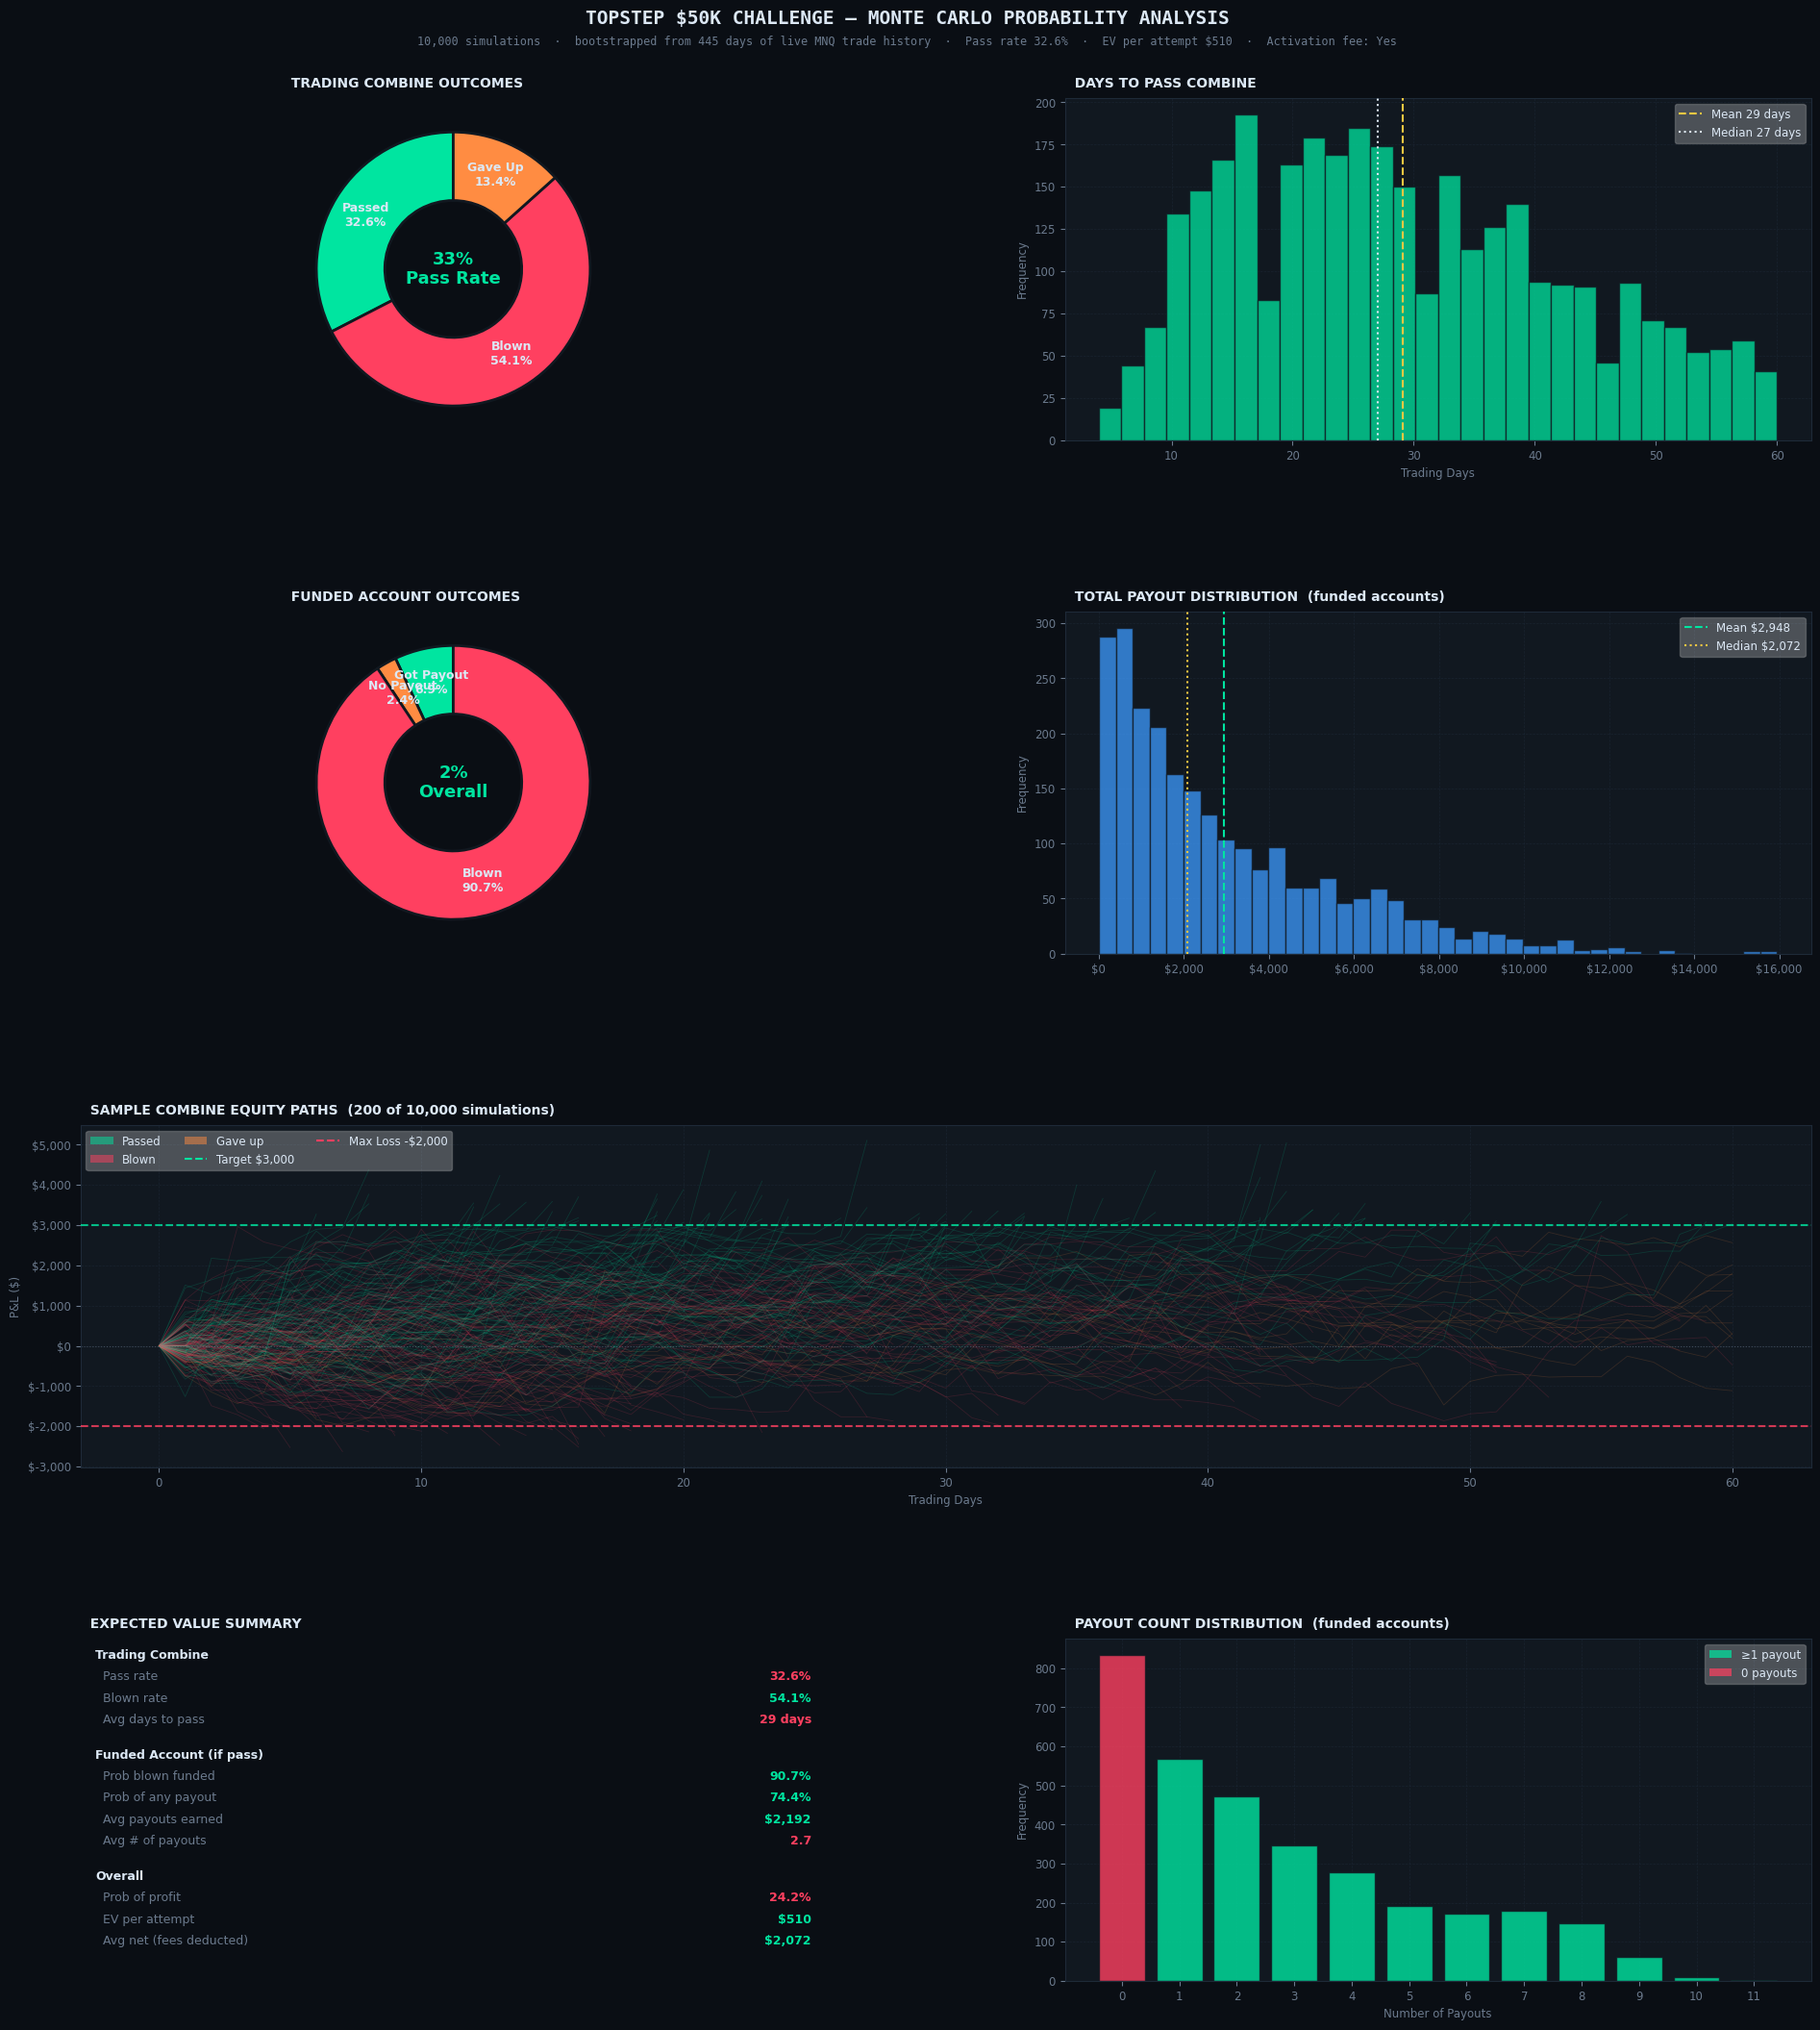

✓ Saved → topstep_monte_carlo.png


In [6]:
# %% [markdown]
# # Topstep Challenge Monte Carlo Simulator
# **Probability of passing, getting funded, and generating payouts**
# All Topstep $50K rules as of 2025/2026.
#
# **Install:**
# ```
# pip install pandas numpy matplotlib scipy
# ```

# %% ── Imports ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

# %% ── CONFIG ─────────────────────────────────────────────────────────────────

TRADES_CSV   = "trades.csv"   # your MNQ trades file
N_SIMS       = 10_000                           # number of simulated paths

# ── Topstep $50K Trading Combine Rules ───────────────────────────────────────
COMBINE_PROFIT_TARGET   = 3_000    # must hit this to get funded
COMBINE_MAX_LOSS        = 2_000    # end-of-day trailing drawdown limit
CONSISTENCY_CAP         = 0.50     # best day must be < 50% of profit target
# Topstep pricing (two options — toggle USE_ACTIVATION below)
#
# Option A — Standard ($49/mo combine + $149 activation fee when you pass)
#   Pay $49/month during combine, then $149 to activate funded account
#
# Option B — Express ($109/mo combine, no activation fee)
#   Higher monthly cost but no surprise fee when you pass
#
# Set to True for Option A, False for Option B
USE_ACTIVATION_FEE      = True
COMBINE_MONTHLY_FEE     = 49  if USE_ACTIVATION_FEE else 109
ACTIVATION_FEE          = 149 if USE_ACTIVATION_FEE else 0
MAX_COMBINE_DAYS        = 60       # max days before giving up (2 months)

# ── Topstep $50K Express Funded Account Rules ─────────────────────────────────
FUNDED_MAX_LOSS         = 2_000    # trailing from highest end-of-day balance
WINNING_DAYS_FOR_PAYOUT = 5        # need 5 winning days ($150+) between payouts
MIN_WINNING_DAY         = 150      # minimum P&L to count as a winning day
MAX_PAYOUT_PCT          = 0.50     # max 50% of balance per payout
MAX_PAYOUT_DOLLARS      = 5_000    # hard cap per payout
TOPSTEP_CUT             = 0.10     # Topstep keeps 10%
FUNDED_SIM_DAYS         = 120      # simulate 4 months of funded trading

# %% ── Load Trade Data ────────────────────────────────────────────────────────
print("Loading trades …")
df = pd.read_csv(TRADES_CSV)
df["Entry Time"] = pd.to_datetime(df["Entry Time"], utc=True).dt.tz_localize(None)
df["Exit Time"]  = pd.to_datetime(df["Exit Time"],  utc=True).dt.tz_localize(None)
df = df.sort_values("Exit Time").reset_index(drop=True)

# Build daily P&L series
df["Date"]  = df["Exit Time"].dt.date
daily_pnl   = df.groupby("Date")["P&L"].sum().values
n_days      = len(daily_pnl)

print(f"  Trading days in history : {n_days}")
print(f"  Mean daily P&L          : ${np.mean(daily_pnl):,.2f}")
print(f"  Std daily P&L           : ${np.std(daily_pnl):,.2f}")
print(f"  % positive days         : {(daily_pnl > 0).mean():.1%}")
print(f"  Best day                : ${np.max(daily_pnl):,.2f}")
print(f"  Worst day               : ${np.min(daily_pnl):,.2f}")

# %% ── Monte Carlo Engine ─────────────────────────────────────────────────────

def simulate_combine(daily_returns: np.ndarray, n_sims: int) -> dict:
    """
    Simulate n_sims Trading Combine attempts by bootstrapping daily P&L.

    Returns dict of outcome lists.
    """
    results = {
        "passed"          : [],   # bool — hit profit target without blowing up
        "blown"           : [],   # bool — hit max loss before profit target
        "days_to_pass"    : [],   # int  — days taken to pass (if passed)
        "best_day"        : [],   # float — best single day profit
        "consistency_ok"  : [],   # bool — consistency rule met
        "total_profit"    : [],   # float — final profit at pass/blow
        "gave_up"         : [],   # bool — hit max days without passing
    }

    for _ in range(n_sims):
        balance      = 0.0
        peak_balance = 0.0
        best_day     = 0.0
        passed       = False
        blown        = False
        gave_up      = False

        for day in range(MAX_COMBINE_DAYS):
            # Bootstrap a random day from historical daily P&L
            pnl      = float(np.random.choice(daily_returns))
            balance += pnl

            # Track peak for trailing drawdown
            if balance > peak_balance:
                peak_balance = balance

            # Track best day for consistency rule
            if pnl > best_day:
                best_day = pnl

            # Check blown — balance dropped > MAX_LOSS from peak
            if peak_balance - balance >= COMBINE_MAX_LOSS:
                blown = True
                break

            # Check passed
            if balance >= COMBINE_PROFIT_TARGET:
                # Check consistency rule
                consistency_ok = best_day < (COMBINE_PROFIT_TARGET * CONSISTENCY_CAP)
                if consistency_ok:
                    passed = True
                    results["days_to_pass"].append(day + 1)
                    results["consistency_ok"].append(True)
                else:
                    # Failed consistency — need more profit
                    # Keep trading until consistency resolves or blown
                    pass

                if passed:
                    break
        else:
            gave_up = True

        results["passed"].append(passed)
        results["blown"].append(blown)
        results["gave_up"].append(gave_up)
        results["best_day"].append(best_day)
        results["total_profit"].append(balance)
        if not passed:
            results["consistency_ok"].append(False)

    return results


def simulate_funded(daily_returns: np.ndarray, n_sims: int) -> dict:
    """
    Simulate n_sims funded account runs using bootstrapped daily P&L.
    Only runs for accounts that passed the combine.
    """
    results = {
        "blown"           : [],
        "total_payouts"   : [],
        "n_payouts"       : [],
        "days_survived"   : [],
        "net_after_fees"  : [],
    }

    for _ in range(n_sims):
        balance        = 0.0
        peak_balance   = 0.0
        total_payouts  = 0.0
        n_payouts      = 0
        winning_days   = 0
        blown          = False
        days_survived  = 0

        for day in range(FUNDED_SIM_DAYS):
            pnl      = float(np.random.choice(daily_returns))
            balance += pnl
            days_survived += 1

            # Track peak for trailing drawdown
            if balance > peak_balance:
                peak_balance = balance

            # Count winning days for payout eligibility
            if pnl >= MIN_WINNING_DAY:
                winning_days += 1

            # Check blown
            if peak_balance - balance >= FUNDED_MAX_LOSS:
                blown = True
                break

            # Check payout eligibility
            if winning_days >= WINNING_DAYS_FOR_PAYOUT and balance > 0:
                # Take a payout
                payout_amount = min(
                    balance * MAX_PAYOUT_PCT,
                    MAX_PAYOUT_DOLLARS
                )
                my_payout    = payout_amount * (1 - TOPSTEP_CUT)
                balance     -= payout_amount
                total_payouts += my_payout
                n_payouts    += 1
                winning_days  = 0  # reset counter

                # After first payout, peak locks at 0
                peak_balance = max(0, peak_balance - payout_amount)

        results["blown"].append(blown)
        results["total_payouts"].append(total_payouts)
        results["n_payouts"].append(n_payouts)
        results["days_survived"].append(days_survived)
        results["net_after_fees"].append(
            total_payouts - (COMBINE_MONTHLY_FEE * (days_survived / 21))
        )

    return results


# %% ── Run Simulations ────────────────────────────────────────────────────────
print(f"\nRunning {N_SIMS:,} combine simulations …")
combine_results = simulate_combine(daily_pnl, N_SIMS)

pass_rate  = np.mean(combine_results["passed"])
blown_rate = np.mean(combine_results["blown"])
gave_up    = np.mean(combine_results["gave_up"])

print(f"  Pass rate        : {pass_rate:.1%}")
print(f"  Blown rate       : {blown_rate:.1%}")
print(f"  Gave up rate     : {gave_up:.1%}")

passed_days = combine_results["days_to_pass"]
if passed_days:
    print(f"  Avg days to pass : {np.mean(passed_days):.1f}")
    print(f"  Median days      : {np.median(passed_days):.0f}")

# Funded simulation — only for accounts that passed
n_funded = int(N_SIMS * pass_rate)
print(f"\nRunning {n_funded:,} funded account simulations …")
funded_results = simulate_funded(daily_pnl, n_funded)

funded_blown      = np.mean(funded_results["blown"])
avg_payouts       = np.mean(funded_results["total_payouts"])
avg_n_payouts     = np.mean(funded_results["n_payouts"])
avg_net           = np.mean(funded_results["net_after_fees"])
prob_any_payout   = np.mean(np.array(funded_results["n_payouts"]) > 0)

print(f"  Prob blown funded    : {funded_blown:.1%}")
print(f"  Prob of any payout   : {prob_any_payout:.1%}")
print(f"  Avg total payouts    : ${avg_payouts:,.2f}")
print(f"  Avg # of payouts     : {avg_n_payouts:.1f}")
print(f"  Avg net (after fees) : ${avg_net:,.2f}")

# Overall expected value per $49 evaluation attempt
# Total cost per attempt:
# Failed attempt = monthly fees for however long you traded
# Passed attempt = monthly fees + activation fee (if applicable)
avg_combine_days     = np.mean(passed_days) if passed_days else MAX_COMBINE_DAYS
avg_combine_fee      = COMBINE_MONTHLY_FEE * (avg_combine_days / 21)
total_cost_if_pass   = avg_combine_fee + ACTIVATION_FEE
total_cost_if_fail   = COMBINE_MONTHLY_FEE * (MAX_COMBINE_DAYS / 21)
ev_per_attempt       = (pass_rate * (avg_net - total_cost_if_pass)
                        - (1 - pass_rate) * total_cost_if_fail)
print(f"  Cost if pass  : ${total_cost_if_pass:,.0f}  (combine fees + activation)")
print(f"  Cost if fail  : ${total_cost_if_fail:,.0f}  (combine fees only)")
print(f"  EV per attempt: ${ev_per_attempt:,.0f}")
print(f"  Prob of profit: {pass_rate * prob_any_payout:.1%}")
print()
print("  Fee option comparison:")
for label, monthly, activation in [
    ("Standard ($49/mo + $149 activation)", 49, 149),
    ("Express  ($109/mo, no activation)  ", 109, 0),
]:
    avg_d  = np.mean(passed_days) if passed_days else MAX_COMBINE_DAYS
    c_pass = monthly * (avg_d / 21) + activation
    c_fail = monthly * (MAX_COMBINE_DAYS / 21)
    ev     = pass_rate * (avg_net - c_pass) - (1 - pass_rate) * c_fail
    print(f"    {label}  ->  EV = ${ev:,.0f}")

# %% ── Visualization ───────────────────────────────────────────────────────────
BG     = "#0a0e14"
PANEL  = "#111820"
BORDER = "#1e2a38"
GREEN  = "#00e5a0"
RED    = "#ff4060"
BLUE   = "#3d9bff"
ORANGE = "#ff8c42"
PURPLE = "#b57bee"
YELLOW = "#f5c842"
GRAY   = "#6b7a8d"
WHITE  = "#dce8f5"

def style_ax(ax, title, ylabel=""):
    ax.set_facecolor(PANEL)
    for sp in ax.spines.values():
        sp.set_edgecolor(BORDER); sp.set_linewidth(0.8)
    ax.tick_params(colors=GRAY, labelsize=8.5)
    ax.set_title(title, color=WHITE, fontsize=10, fontweight="bold", pad=8, loc="left")
    if ylabel:
        ax.set_ylabel(ylabel, color=GRAY, fontsize=8.5)
    ax.grid(True, color=BORDER, linewidth=0.5, linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)


fig = plt.figure(figsize=(20, 22), facecolor=BG)
gs  = gridspec.GridSpec(4, 2, figure=fig,
                        hspace=0.50, wspace=0.32,
                        left=0.07, right=0.97, top=0.93, bottom=0.04)

# ── Panel 1 : Combine outcome donut (full width) ──────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(PANEL)
ax1.set_title("  TRADING COMBINE OUTCOMES", color=WHITE,
              fontsize=10, fontweight="bold", pad=8, loc="left")

sizes  = [pass_rate, blown_rate, gave_up]
colors = [GREEN, RED, ORANGE]
labels = [f"Passed\n{pass_rate:.1%}", f"Blown\n{blown_rate:.1%}", f"Gave Up\n{gave_up:.1%}"]
wedges, texts = ax1.pie(sizes, colors=colors, startangle=90,
                         wedgeprops=dict(width=0.5, edgecolor=PANEL, linewidth=2))
for i, (wedge, label) in enumerate(zip(wedges, labels)):
    angle  = (wedge.theta2 + wedge.theta1) / 2
    x      = 0.75 * np.cos(np.radians(angle))
    y      = 0.75 * np.sin(np.radians(angle))
    ax1.text(x, y, label, ha="center", va="center",
             color=WHITE, fontsize=9, fontweight="bold")

ax1.text(0, 0, f"{pass_rate:.0%}\nPass Rate",
         ha="center", va="center", color=GREEN, fontsize=13, fontweight="bold")

# ── Panel 2 : Days to pass histogram ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2, "  DAYS TO PASS COMBINE", "Frequency")

if passed_days:
    ax2.hist(passed_days, bins=30, color=GREEN, alpha=0.75, edgecolor=PANEL, zorder=2)
    ax2.axvline(np.mean(passed_days), color=YELLOW, linewidth=1.5, linestyle="--",
                label=f"Mean {np.mean(passed_days):.0f} days", zorder=3)
    ax2.axvline(np.median(passed_days), color=WHITE, linewidth=1.5, linestyle=":",
                label=f"Median {np.median(passed_days):.0f} days", zorder=3)
    ax2.legend(framealpha=0.25, labelcolor=WHITE, fontsize=8.5)
    ax2.set_xlabel("Trading Days", color=GRAY, fontsize=8.5)

# ── Panel 3 : Funded outcome donut ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor(PANEL)
ax3.set_title("  FUNDED ACCOUNT OUTCOMES", color=WHITE,
              fontsize=10, fontweight="bold", pad=8, loc="left")

funded_survive = 1 - funded_blown
f_sizes  = [prob_any_payout * funded_survive,
            (1 - prob_any_payout) * funded_survive,
            funded_blown]
f_colors = [GREEN, ORANGE, RED]
f_labels = [f"Got Payout\n{prob_any_payout * funded_survive:.1%}",
            f"No Payout\n{(1-prob_any_payout)*funded_survive:.1%}",
            f"Blown\n{funded_blown:.1%}"]
wedges2, _ = ax3.pie(f_sizes, colors=f_colors, startangle=90,
                      wedgeprops=dict(width=0.5, edgecolor=PANEL, linewidth=2))
for i, (wedge, label) in enumerate(zip(wedges2, f_labels)):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x     = 0.75 * np.cos(np.radians(angle))
    y     = 0.75 * np.sin(np.radians(angle))
    ax3.text(x, y, label, ha="center", va="center",
             color=WHITE, fontsize=9, fontweight="bold")

overall_prob = pass_rate * prob_any_payout * funded_survive
ax3.text(0, 0, f"{overall_prob:.0%}\nOverall",
         ha="center", va="center", color=GREEN, fontsize=13, fontweight="bold")

# ── Panel 4 : Payout distribution ────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
style_ax(ax4, "  TOTAL PAYOUT DISTRIBUTION  (funded accounts)", "Frequency")

payouts = np.array(funded_results["total_payouts"])
payouts_nonzero = payouts[payouts > 0]
if len(payouts_nonzero) > 0:
    ax4.hist(payouts_nonzero, bins=40, color=BLUE, alpha=0.75,
             edgecolor=PANEL, zorder=2)
    ax4.axvline(np.mean(payouts_nonzero), color=GREEN, linewidth=1.5,
                linestyle="--", label=f"Mean ${np.mean(payouts_nonzero):,.0f}", zorder=3)
    ax4.axvline(np.median(payouts_nonzero), color=YELLOW, linewidth=1.5,
                linestyle=":", label=f"Median ${np.median(payouts_nonzero):,.0f}", zorder=3)
    ax4.legend(framealpha=0.25, labelcolor=WHITE, fontsize=8.5)
    ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))

# ── Panel 5 : Simulated combine equity paths (sample 200) ─────────────────────
ax5 = fig.add_subplot(gs[2, :])
style_ax(ax5,
         f"  SAMPLE COMBINE EQUITY PATHS  (200 of {N_SIMS:,} simulations)",
         "P&L ($)")

sample_n = min(200, N_SIMS)
for _ in range(sample_n):
    path    = [0.0]
    balance = 0.0
    peak    = 0.0
    color   = None
    for day in range(MAX_COMBINE_DAYS):
        pnl      = float(np.random.choice(daily_pnl))
        balance += pnl
        if balance > peak:
            peak = balance
        path.append(balance)
        if peak - balance >= COMBINE_MAX_LOSS:
            color = RED
            break
        if balance >= COMBINE_PROFIT_TARGET:
            color = GREEN
            break
    if color is None:
        color = ORANGE
    ax5.plot(path, color=color, alpha=0.15, linewidth=0.6, zorder=1)

ax5.axhline(COMBINE_PROFIT_TARGET, color=GREEN, linewidth=1.5,
            linestyle="--", alpha=0.8, label=f"Profit Target ${COMBINE_PROFIT_TARGET:,}", zorder=3)
ax5.axhline(-COMBINE_MAX_LOSS, color=RED, linewidth=1.5,
            linestyle="--", alpha=0.8, label=f"Max Loss -${COMBINE_MAX_LOSS:,}", zorder=3)
ax5.axhline(0, color=GRAY, linewidth=0.8, linestyle=":", alpha=0.5, zorder=2)

from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor=GREEN,  alpha=0.5, label="Passed"),
    Patch(facecolor=RED,    alpha=0.5, label="Blown"),
    Patch(facecolor=ORANGE, alpha=0.5, label="Gave up"),
    plt.Line2D([0],[0], color=GREEN,  linestyle="--", label=f"Target ${COMBINE_PROFIT_TARGET:,}"),
    plt.Line2D([0],[0], color=RED,    linestyle="--", label=f"Max Loss -${COMBINE_MAX_LOSS:,}"),
]
ax5.legend(handles=legend_els, loc="upper left",
           framealpha=0.25, labelcolor=WHITE, fontsize=8.5, ncol=3)
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax5.set_xlabel("Trading Days", color=GRAY, fontsize=8.5)

# ── Panel 6 : Expected value summary ─────────────────────────────────────────
ax6 = fig.add_subplot(gs[3, 0])
ax6.set_facecolor(PANEL)
for sp in ax6.spines.values():
    sp.set_edgecolor(BORDER)
ax6.set_title("  EXPECTED VALUE SUMMARY", color=WHITE,
              fontsize=10, fontweight="bold", pad=8, loc="left")
ax6.axis("off")

summary_lines = [
    ("Trading Combine",                  ""),
    (f"  Pass rate",                     f"{pass_rate:.1%}"),
    (f"  Blown rate",                    f"{blown_rate:.1%}"),
    (f"  Avg days to pass",              f"{np.mean(passed_days):.0f} days" if passed_days else "N/A"),
    ("", ""),
    ("Funded Account (if pass)",         ""),
    (f"  Prob blown funded",             f"{funded_blown:.1%}"),
    (f"  Prob of any payout",            f"{prob_any_payout:.1%}"),
    (f"  Avg payouts earned",            f"${avg_payouts:,.0f}"),
    (f"  Avg # of payouts",              f"{avg_n_payouts:.1f}"),
    ("", ""),
    ("Overall",                          ""),
    (f"  Prob of profit",                f"{pass_rate * prob_any_payout:.1%}"),
    (f"  EV per attempt",            f"${ev_per_attempt:,.0f}"),
    (f"  Avg net (fees deducted)",       f"${avg_net:,.0f}"),
]

y = 0.97
for label, value in summary_lines:
    if label == "" :
        y -= 0.04
        continue
    is_header = not label.startswith("  ")
    color     = WHITE if is_header else GRAY
    weight    = "bold" if is_header else "normal"
    ax6.text(0.02, y, label, transform=ax6.transAxes,
             color=color, fontsize=9, fontweight=weight, va="top")
    if value:
        val_color = GREEN if ("%" in value and float(value.strip("%").replace(",","")) > 50) or \
                             ("$" in value and float(value.replace("$","").replace(",","").strip()) > 0) \
                    else RED
        ax6.text(0.98, y, value, transform=ax6.transAxes,
                 color=val_color, fontsize=9, fontweight="bold", va="top", ha="right")
    y -= 0.063

# ── Panel 7 : Number of payouts distribution ─────────────────────────────────
ax7 = fig.add_subplot(gs[3, 1])
style_ax(ax7, "  PAYOUT COUNT DISTRIBUTION  (funded accounts)", "Frequency")

n_payouts_arr = np.array(funded_results["n_payouts"])
max_p = int(n_payouts_arr.max()) if len(n_payouts_arr) > 0 else 0
bins  = np.arange(-0.5, max_p + 1.5, 1)
counts, edges = np.histogram(n_payouts_arr, bins=bins)
centers = (edges[:-1] + edges[1:]) / 2
bar_colors = [RED if c == 0 else GREEN for c in centers]
ax7.bar(centers, counts, width=0.8, color=bar_colors, alpha=0.80,
        edgecolor=PANEL, zorder=2)
ax7.set_xticks(range(max_p + 1))
ax7.set_xticklabels([str(i) for i in range(max_p + 1)], color=GRAY)
ax7.set_xlabel("Number of Payouts", color=GRAY, fontsize=8.5)

from matplotlib.patches import Patch as P2
ax7.legend(handles=[P2(facecolor=GREEN, alpha=0.7, label="≥1 payout"),
                    P2(facecolor=RED,   alpha=0.7, label="0 payouts")],
           framealpha=0.25, labelcolor=WHITE, fontsize=8.5)

# ── Master title ──────────────────────────────────────────────────────────────
fig.text(0.5, 0.965,
         "TOPSTEP $50K CHALLENGE — MONTE CARLO PROBABILITY ANALYSIS",
         ha="center", color=WHITE, fontsize=14,
         fontweight="bold", fontfamily="monospace")
fig.text(0.5, 0.955,
         f"{N_SIMS:,} simulations  ·  bootstrapped from {n_days} days of live MNQ trade history  ·  "
         f"Pass rate {pass_rate:.1%}  ·  EV per attempt ${ev_per_attempt:,.0f}  ·  Activation fee: {"Yes" if USE_ACTIVATION_FEE else "No"}",
         ha="center", color=GRAY, fontsize=8.5, fontfamily="monospace")

plt.savefig("topstep_monte_carlo.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("✓ Saved → topstep_monte_carlo.png")